# 03 — KPI Dashboard
Compute the core business KPIs and build a clean, presentation-ready set of charts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('../data/processed/superstore_clean.csv', parse_dates=['order_date'])
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,sales,quantity,discount,profit,order_year,order_month,order_year_month,order_quarter,profit_margin,fulfillment_days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,261.9600,2,0.00,41.9136,2016,11,2016-11,2016Q4,0.1600,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,731.9400,3,0.00,219.5820,2016,11,2016-11,2016Q4,0.3000,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,14.6200,2,0.00,6.8714,2016,6,2016-06,2016Q2,0.4700,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,957.5775,5,0.45,-383.0310,2015,10,2015-10,2015Q4,-0.4000,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,22.3680,2,0.20,2.5164,2015,10,2015-10,2015Q4,0.1125,7


## 1. Core KPI functions

In [2]:
def revenue(d):
    return d['sales'].sum()

def profit(d):
    return d['profit'].sum()

def profit_margin(d):
    return d['profit'].sum() / d['sales'].sum()

def average_order_value(d):
    order_totals = d.groupby('order_id')['sales'].sum()
    return order_totals.mean()

def growth_rate(monthly_series):
    """Month-over-month % growth for a series indexed by period."""
    return monthly_series.pct_change()

def yoy_growth(d, value_col='sales'):
    yearly = d.groupby('order_year')[value_col].sum()
    return yearly.pct_change()

def repeat_customer_rate(d):
    orders_per_customer = d.groupby('customer_id')['order_id'].nunique()
    return (orders_per_customer > 1).mean()

## 2. Headline KPIs

In [3]:
kpis = {
    'Total Revenue': f"${revenue(df):,.0f}",
    'Total Profit': f"${profit(df):,.0f}",
    'Profit Margin': f"{profit_margin(df):.2%}",
    'Average Order Value': f"${average_order_value(df):,.2f}",
    'Repeat Customer Rate': f"{repeat_customer_rate(df):.1%}",
    'Total Orders': f"{df['order_id'].nunique():,}",
    'Total Customers': f"{df['customer_id'].nunique():,}",
}
for k, v in kpis.items():
    print(f"{k:<22}: {v}")

Total Revenue         : $2,297,201
Total Profit          : $286,397
Profit Margin         : 12.47%
Average Order Value   : $458.61
Repeat Customer Rate  : 98.5%
Total Orders          : 5,009
Total Customers       : 793


## 3. Monthly revenue with MoM growth

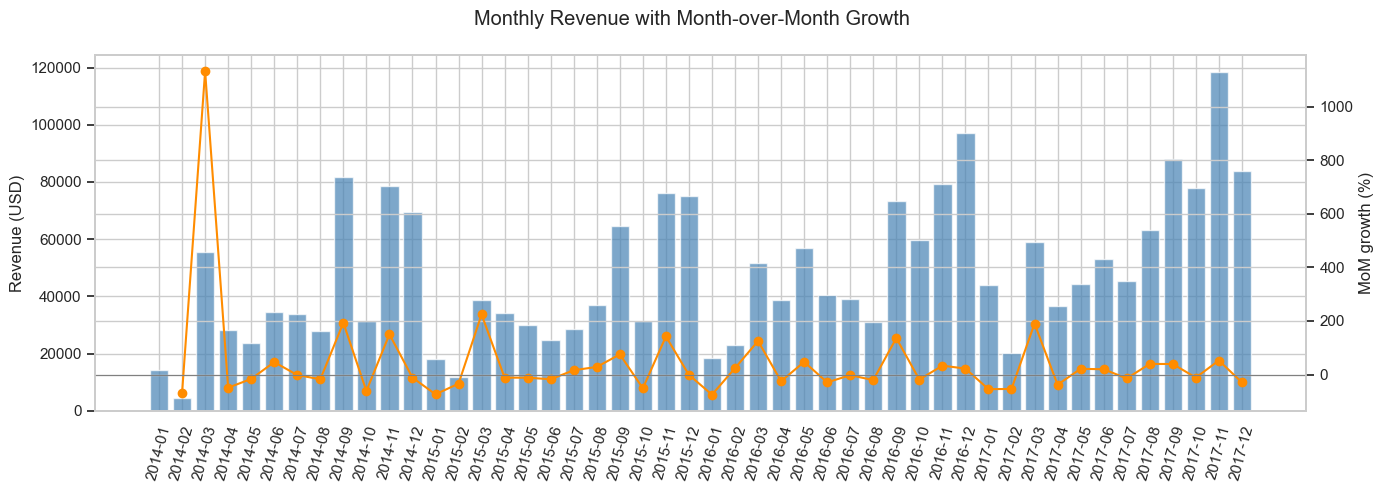

Average MoM growth: 41.56%
Best month: 2014-03 (1132.13%)
Worst month: 2016-01 (-75.25%)


In [4]:
monthly_sales = df.groupby('order_year_month')['sales'].sum().sort_index()
mom_growth = growth_rate(monthly_sales)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.bar(monthly_sales.index, monthly_sales.values, color='steelblue', alpha=0.7, label='Revenue')
ax1.set_ylabel('Revenue (USD)')
ax1.tick_params(axis='x', rotation=75)

ax2 = ax1.twinx()
ax2.plot(monthly_sales.index, mom_growth.values * 100, color='darkorange', marker='o', label='MoM growth %')
ax2.set_ylabel('MoM growth (%)')
ax2.axhline(0, color='gray', linewidth=0.8)

fig.suptitle('Monthly Revenue with Month-over-Month Growth')
fig.tight_layout()
plt.savefig('../reports/figures/kpi_monthly_revenue_growth.png', dpi=150)
plt.show()

print(f"Average MoM growth: {mom_growth.mean():.2%}")
print(f"Best month: {mom_growth.idxmax()} ({mom_growth.max():.2%})")
print(f"Worst month: {mom_growth.idxmin()} ({mom_growth.min():.2%})")

## 4. Year-over-year growth

order_year
2014         NaN
2015   -0.028322
2016    0.294715
2017    0.203560
Name: sales, dtype: float64


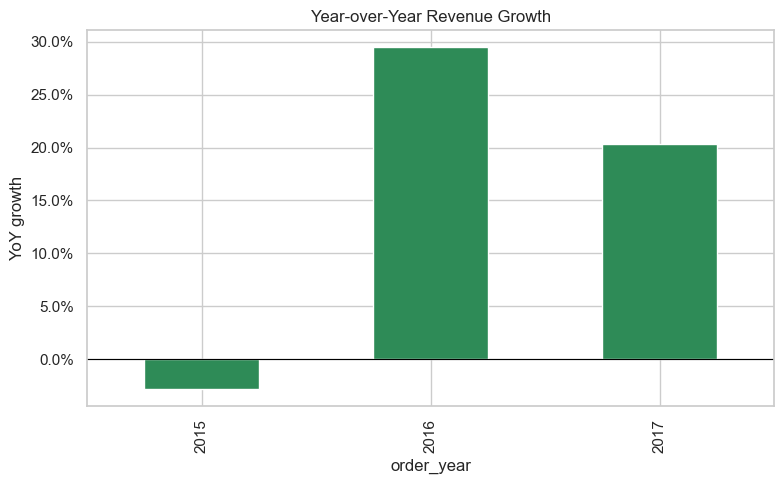

In [5]:
yoy = yoy_growth(df)
print(yoy)

plt.figure(figsize=(8, 5))
yoy.dropna().plot(kind='bar', color='seagreen')
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel('YoY growth')
plt.title('Year-over-Year Revenue Growth')
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.savefig('../reports/figures/kpi_yoy_growth.png', dpi=150)
plt.show()

## 5. Profit margin trend

C:\Users\Aagam Shah\AppData\Local\Temp\ipykernel_9324\816155196.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_margin = df.groupby('order_year_month').apply(lambda d: d['profit'].sum() / d['sales'].sum())


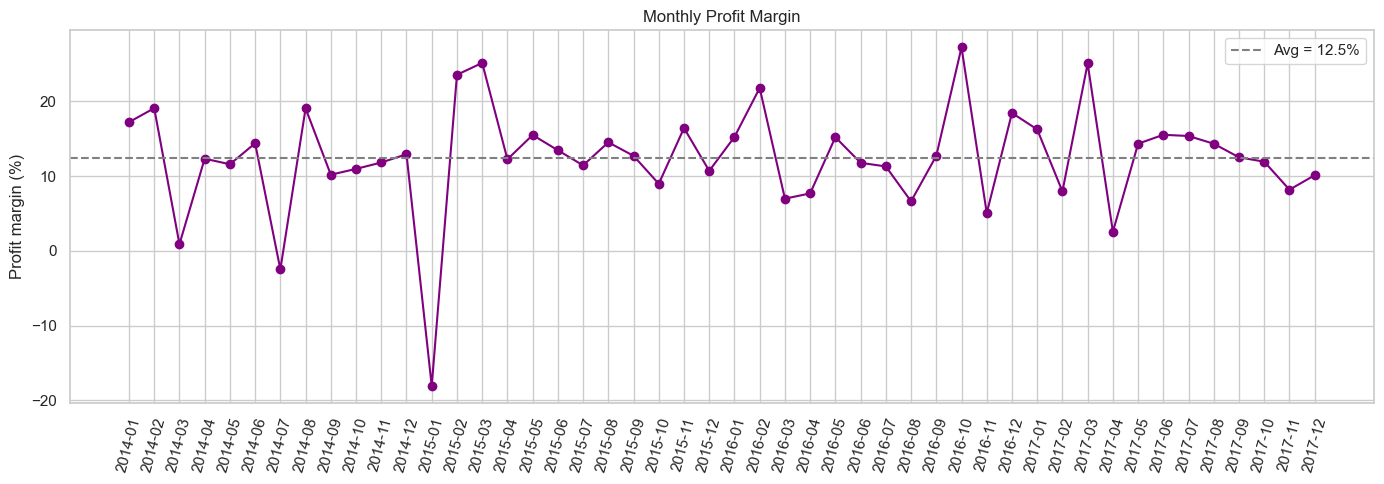

In [6]:
monthly_margin = df.groupby('order_year_month').apply(lambda d: d['profit'].sum() / d['sales'].sum())

plt.figure(figsize=(14, 5))
plt.plot(monthly_margin.index, monthly_margin.values * 100, marker='o', color='purple')
plt.axhline(monthly_margin.mean() * 100, color='gray', linestyle='--', label=f"Avg = {monthly_margin.mean():.1%}")
plt.xticks(rotation=75)
plt.ylabel('Profit margin (%)')
plt.title('Monthly Profit Margin')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/kpi_monthly_margin.png', dpi=150)
plt.show()

## 6. KPI summary table by category

In [7]:
kpi_by_category = df.groupby('category').apply(
    lambda d: pd.Series({
        'revenue': revenue(d),
        'profit': profit(d),
        'margin': profit_margin(d),
        'aov': average_order_value(d),
    })
).sort_values('revenue', ascending=False)
kpi_by_category

C:\Users\Aagam Shah\AppData\Local\Temp\ipykernel_9324\1905886879.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  kpi_by_category = df.groupby('category').apply(


,revenue,profit,margin,aov
category,,,,
Technology,836154.0330,145454.9481,0.173957,541.550540
Furniture,741999.7953,18451.2728,0.024867,420.634805
Office Supplies,719047.0320,122490.8008,0.170352,192.155808


## 7. Save the KPI summary for the README

In [8]:
summary_rows = []
summary_rows.append(('Total Revenue', revenue(df)))
summary_rows.append(('Total Profit', profit(df)))
summary_rows.append(('Overall Margin', profit_margin(df)))
summary_rows.append(('Average Order Value', average_order_value(df)))
summary_rows.append(('Repeat Customer Rate', repeat_customer_rate(df)))
summary_rows.append(('Avg MoM Growth', mom_growth.mean()))

kpi_summary_df = pd.DataFrame(summary_rows, columns=['KPI', 'Value'])
kpi_summary_df.to_csv('../reports/kpi_summary.csv', index=False)
kpi_summary_df

,KPI,Value
0,Total Revenue,2.297201e+06
1,Total Profit,2.863970e+05
2,Overall Margin,1.246722e-01
3,Average Order Value,4.586147e+02
4,Repeat Customer Rate,9.848676e-01
5,Avg MoM Growth,4.156455e-01
